# 教室用電量與課堂數線性回歸分析
- **X軸**：課堂數（從 classroom_usage_day 資料取得）
- **Y軸**：扣除基礎後功率_kW（從 扣除星期六基礎功率 資料取得）
- **建築物**：共同、博雅、普通、新生（共4棟）

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# ── 設定中文字型 ──────────────────────────────────────────
# 嘗試常見中文字型（Windows / macOS / Linux 均可）
chinese_fonts = [
    'Microsoft JhengHei', 'Microsoft YaHei',
    'PingFang TC', 'Heiti TC', 'Noto Sans CJK TC',
    'WenQuanYi Micro Hei', 'SimHei', 'Arial Unicode MS'
]
available = {f.name for f in fm.fontManager.ttflist}
chosen_font = next((f for f in chinese_fonts if f in available), None)
if chosen_font:
    plt.rcParams['font.family'] = chosen_font
else:
    print('⚠️  找不到中文字型，標題可能顯示為方塊，請手動安裝字型。')
plt.rcParams['axes.unicode_minus'] = False
print('字型設定完成：', chosen_font)

字型設定完成： Microsoft JhengHei


In [4]:
# ── 參數設定（請依實際資料夾路徑修改） ────────────────────
DATA_DIR ='C:/Users/User/Documents/台大碩一下/環境資料科學/final_report'

BUILDINGS = ['共同', '博雅', '普通', '新生']

# 時間區間 → 堂次對照（一天從 07:00 開始，每節 1 小時）
# classroom_usage_day 的欄位名稱範例：08:00~09:00 … 17:00~18:00
# 此對照表用來確認哪些時間區間屬於「上午」或「下午」
MORNING_SLOTS   = ['07:00~08:00', '08:00~09:00', '09:00~10:00',
                   '10:00~11:00', '11:00~12:00']
AFTERNOON_SLOTS = ['13:00~14:00', '14:00~15:00', '15:00~16:00',
                   '16:00~17:00', '17:00~18:00']
EXCLUDE_SLOTS   = ['12:00~13:00']   # 午休排除

print('參數設定完成')

參數設定完成


In [5]:
# ── 讀取資料函式 ───────────────────────────────────────────

def read_file(path):
    """依副檔名選擇讀取方式，CSV 自動偵測編碼。"""
    if path.lower().endswith('.csv'):
        for enc in ['utf-8-sig', 'big5', 'gbk', 'utf-8']:
            try:
                return pd.read_csv(path, encoding=enc)
            except (UnicodeDecodeError, Exception):
                continue
        raise ValueError(f'無法以常見編碼讀取 {path}')
    else:
        return pd.read_excel(path)


def find_file(directory, keyword):
    """在 directory 中找出檔名含 keyword 的第一個 xlsx/xls/csv 檔案。"""
    patterns = [
        os.path.join(directory, f'*{keyword}*.xlsx'),
        os.path.join(directory, f'*{keyword}*.xls'),
        os.path.join(directory, f'*{keyword}*.csv'),
    ]
    for pattern in patterns:
        files = glob.glob(pattern)
        if files:
            return files[0]
    return None


def load_power_data(building):
    """載入用電量資料（扣除星期六基礎功率_0700_1800）。"""
    path = find_file(DATA_DIR, f'{building}_扣除星期六基礎功率_0700_1800')
    if path is None:
        raise FileNotFoundError(f'找不到 {building} 的用電量資料！請確認檔名格式。')
    df = read_file(path)
    df.columns = df.columns.str.strip()
    required = ['年度學期', '星期', '時間區間', '扣除基礎後功率_kW']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'{building} 用電量資料缺少欄位：{missing}\n現有欄位：{list(df.columns)}')
    print(f'  ✔ {building} 用電量：{len(df)} 筆，來源：{os.path.basename(path)}')
    return df[required]


def load_classroom_data(building):
    """載入課堂數資料（classroom_usage_day）。"""
    path = find_file(DATA_DIR, f'{building}_classroom_usage_day')
    if path is None:
        raise FileNotFoundError(f'找不到 {building} 的課堂數資料！請確認檔名格式。')
    df = read_file(path)
    df.columns = df.columns.str.strip()
    print(f'  ✔ {building} 課堂數：{len(df)} 筆，來源：{os.path.basename(path)}')
    return df


def melt_classroom(df_cls):
    sem_col = next((c for c in df_cls.columns if '學期' in c), None)
    day_col = next((c for c in df_cls.columns if '星期' in c), None)
    if sem_col is None or day_col is None:
        raise ValueError(f'找不到學期或星期欄位，現有欄位：{list(df_cls.columns)}')

    time_cols = [c for c in df_cls.columns if '~' in str(c) or ':' in str(c)]
    id_cols   = [sem_col, day_col]

    df_long = df_cls[id_cols + time_cols].melt(
        id_vars=id_cols,
        value_vars=time_cols,
        var_name='時間區間',
        value_name='課堂數'
    )
    df_long = df_long.rename(columns={sem_col: '年度學期', day_col: '星期'})

    # ★ 格式統一：1131 → 113-1
    df_long['年度學期'] = (
        df_long['年度學期']
        .astype(str).str.strip()
        .apply(lambda x: f'{x[:3]}-{x[3]}' if len(x) == 4 and '-' not in x else x)
    )
    df_long['星期']     = df_long['星期'].astype(str).str.strip()
    df_long['時間區間'] = df_long['時間區間'].astype(str).str.strip()
    df_long['課堂數']   = pd.to_numeric(df_long['課堂數'], errors='coerce')
    return df_long


def merge_data(building):
    """合併用電量與課堂數，回傳合併後的 DataFrame。"""
    df_pwr = load_power_data(building)
    df_cls = load_classroom_data(building)
    df_cls_long = melt_classroom(df_cls)

    for df in [df_pwr, df_cls_long]:
        df['年度學期'] = df['年度學期'].astype(str).str.strip()
        df['星期']     = df['星期'].astype(str).str.strip()
        df['時間區間'] = df['時間區間'].astype(str).str.strip()

    merged = df_pwr.merge(
        df_cls_long,
        on=['年度學期', '星期', '時間區間'],
        how='inner'
    )
    merged = merged.dropna(subset=['扣除基礎後功率_kW', '課堂數'])
    merged['建築'] = building
    print(f'  ✔ {building} 合併後：{len(merged)} 筆有效資料')
    return merged


print('函式定義完成')

函式定義完成


In [6]:
# ── 讀取並合併所有建築資料 ─────────────────────────────────
all_data = {}
all_frames = []

for bld in BUILDINGS:
    print(f'\n=== {bld} ===')
    try:
        df = merge_data(bld)
        all_data[bld] = df
        all_frames.append(df)
    except Exception as e:
        print(f'  ✘ {bld} 讀取失敗：{e}')

df_all = pd.concat(all_frames, ignore_index=True) if all_frames else pd.DataFrame()
print(f'\n✅ 全部合併完成，總筆數：{len(df_all)}')
df_all.head()


=== 共同 ===
  ✔ 共同 用電量：220 筆，來源：共同_扣除星期六基礎功率_0700_1800.csv
  ✔ 共同 課堂數：20 筆，來源：共同_classroom_usage_day.csv
  ✔ 共同 合併後：180 筆有效資料

=== 博雅 ===
  ✔ 博雅 用電量：220 筆，來源：博雅_扣除星期六基礎功率_0700_1800.csv
  ✔ 博雅 課堂數：20 筆，來源：博雅_classroom_usage_day.csv
  ✔ 博雅 合併後：180 筆有效資料

=== 普通 ===
  ✔ 普通 用電量：220 筆，來源：普通_扣除星期六基礎功率_0700_1800.csv
  ✔ 普通 課堂數：20 筆，來源：普通_classroom_usage_day.csv
  ✔ 普通 合併後：180 筆有效資料

=== 新生 ===
  ✔ 新生 用電量：220 筆，來源：新生_扣除星期六基礎功率_0700_1800.csv
  ✔ 新生 課堂數：20 筆，來源：新生_classroom_usage_day.csv
  ✔ 新生 合併後：180 筆有效資料

✅ 全部合併完成，總筆數：720


,年度學期,星期,時間區間,扣除基礎後功率_kW,課堂數,建築
0,113-1,星期一,08:00~09:00,30.786795,5,共同
1,113-1,星期一,09:00~10:00,69.199038,17,共同
2,113-1,星期一,10:00~11:00,81.676667,23,共同
3,113-1,星期一,11:00~12:00,103.801259,23,共同
4,113-1,星期一,12:00~13:00,93.685385,12,共同


In [7]:
# ── 匯出合併後的完整資料 ───────────────────────────────────
df_all.to_csv('merged_all_buildings.csv', index=False, encoding='utf-8-sig')
print(f'✅ 已匯出 merged_all_buildings.csv，共 {len(df_all)} 筆')


✅ 已匯出 merged_all_buildings.csv，共 720 筆


In [8]:
# ── 繪圖輔助函式 ───────────────────────────────────────────



def plot_regression(ax, x, y, title, color='steelblue', show_eq=True, ylim=None):
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    if len(x) < 2:
        ax.set_title(f'{title}\n（資料不足）', fontsize=12)
        return

    slope, intercept, r, p, se = stats.linregress(x, y)
    r2 = r ** 2

    ax.scatter(x, y, alpha=0.4, s=20, color=color, label='資料點')
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label='回歸線')

    sign = '+' if intercept >= 0 else '-'
    eq   = f'y = {slope:.3f}x {sign} {abs(intercept):.2f}'
    info = f'R² = {r2:.4f}   p = {p:.2e}   n = {len(x)}'
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('課堂數', fontsize=11)
    ax.set_ylabel('扣除基礎後功率 (kW)', fontsize=11)
    if ylim is not None:
        ax.set_ylim(ylim)
    if show_eq:
        ax.text(0.05, 0.95, f'{eq}\n{info}',
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)


def get_ylim(dfs):
    """計算多個 DataFrame 的共同 Y 軸範圍（含 10% 邊距）。"""
    all_y = pd.concat([df['扣除基礎後功率_kW'] for df in dfs if len(df) > 0])
    all_y = pd.to_numeric(all_y, errors='coerce').dropna()
    margin = (all_y.max() - all_y.min()) * 0.1
    return (all_y.min() - margin, all_y.max() + margin)

def filter_by_time(df, period):
    """
    period: 'morning' / 'afternoon' / 'all'
    排除 12:00~13:00；morning = 07~12，afternoon = 13~18
    """
    df = df[~df['時間區間'].isin(EXCLUDE_SLOTS)]
    if period == 'morning':
        return df[df['時間區間'].isin(MORNING_SLOTS)]
    elif period == 'afternoon':
        return df[df['時間區間'].isin(AFTERNOON_SLOTS)]
    return df


PALETTE = {'共同': '#4C72B0', '博雅': '#55A868', '普通': '#C44E52', '新生': '#8172B2'}
PERIOD_LABEL = {'morning': '上午 (08:00~12:00)', 'afternoon': '下午 (13:00~18:00)'}

print('繪圖函式定義完成')

繪圖函式定義完成


---
## Part 1：各建築物整體回歸 + 全體整體回歸（共 5 張圖）

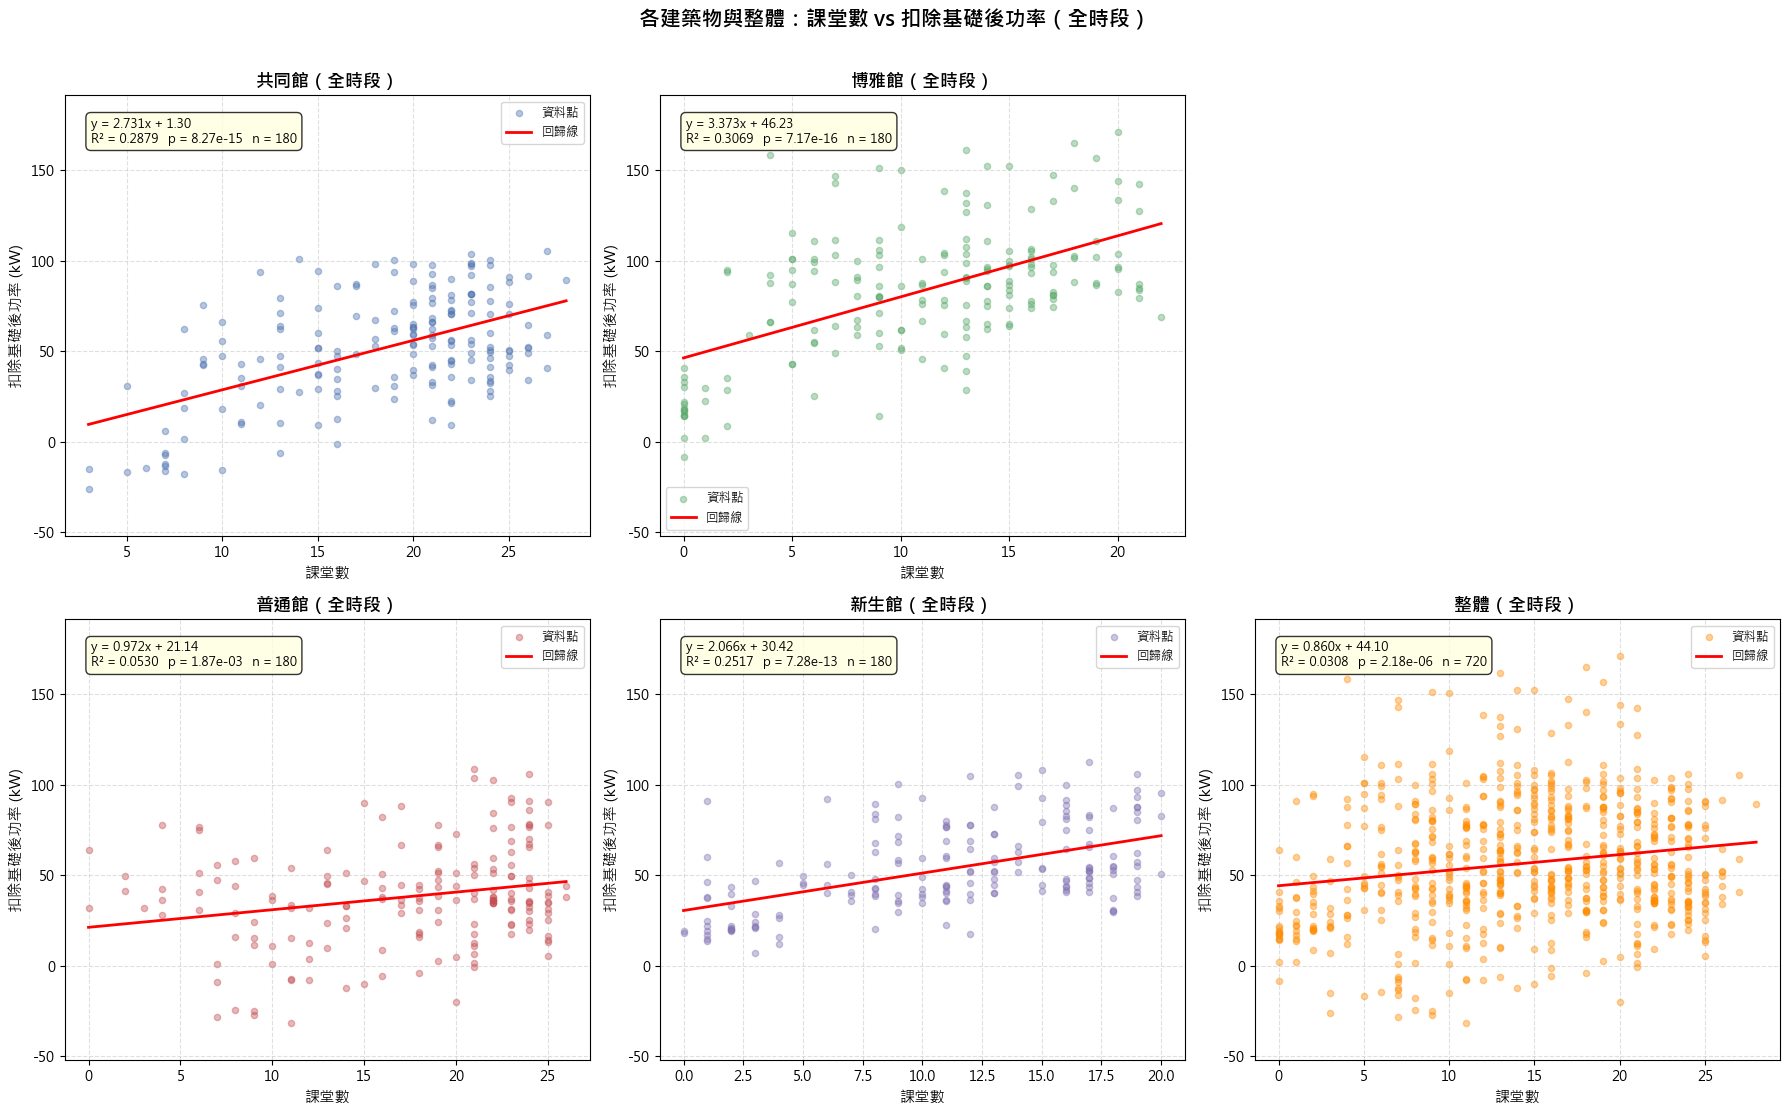

✅ Part 1 完成


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('各建築物與整體：課堂數 vs 扣除基礎後功率（全時段）',
             fontsize=15, fontweight='bold', y=1.01)

# 計算共同 Y 軸範圍
valid_dfs = [all_data[b] for b in BUILDINGS if b in all_data] + [df_all]
ylim = get_ylim(valid_dfs)

for i, bld in enumerate(BUILDINGS):
    ax = axes[i // 2][i % 2]
    if bld not in all_data or len(all_data[bld]) == 0:
        ax.set_visible(False)
        continue
    df = all_data[bld]
    plot_regression(ax, df['課堂數'], df['扣除基礎後功率_kW'],
                    f'{bld}館（全時段）', color=PALETTE[bld], ylim=ylim)

ax5 = axes[1][2]
if len(df_all) > 0:
    plot_regression(ax5, df_all['課堂數'], df_all['扣除基礎後功率_kW'],
                    '整體（全時段）', color='darkorange', ylim=ylim)

axes[0][2].set_visible(False)
plt.tight_layout()
plt.savefig('Part1_整體回歸_5張.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Part 1 完成')

---
## Part 2：去除 12:00~13:00，上午 / 下午 × 各建築（8 張）＋上下午整體（2 張）

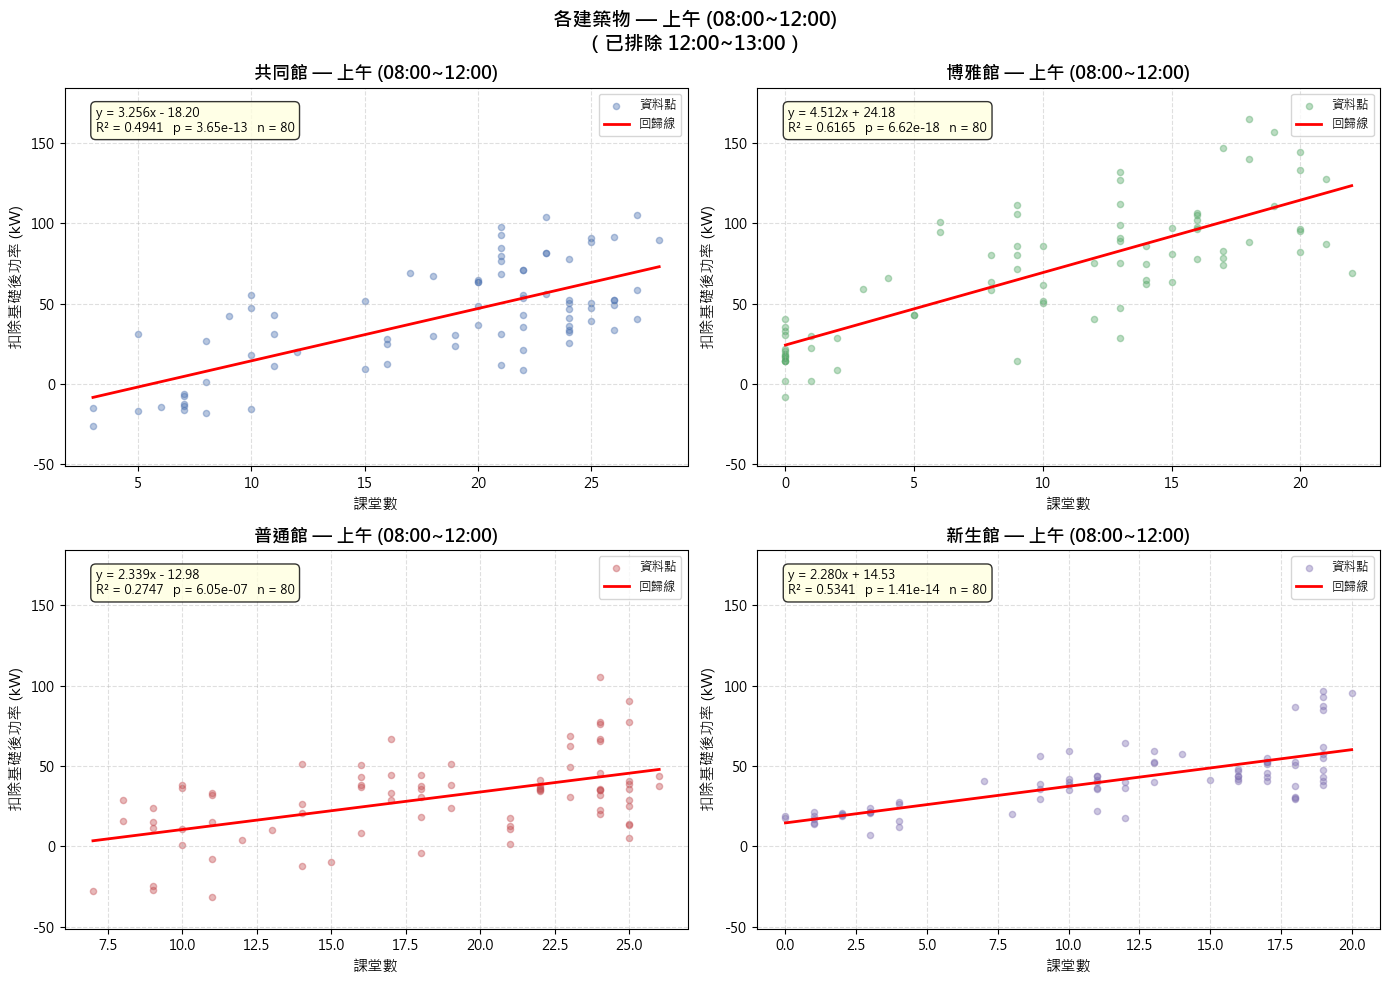

✅ 已存檔 Part2_morning_各建築.png


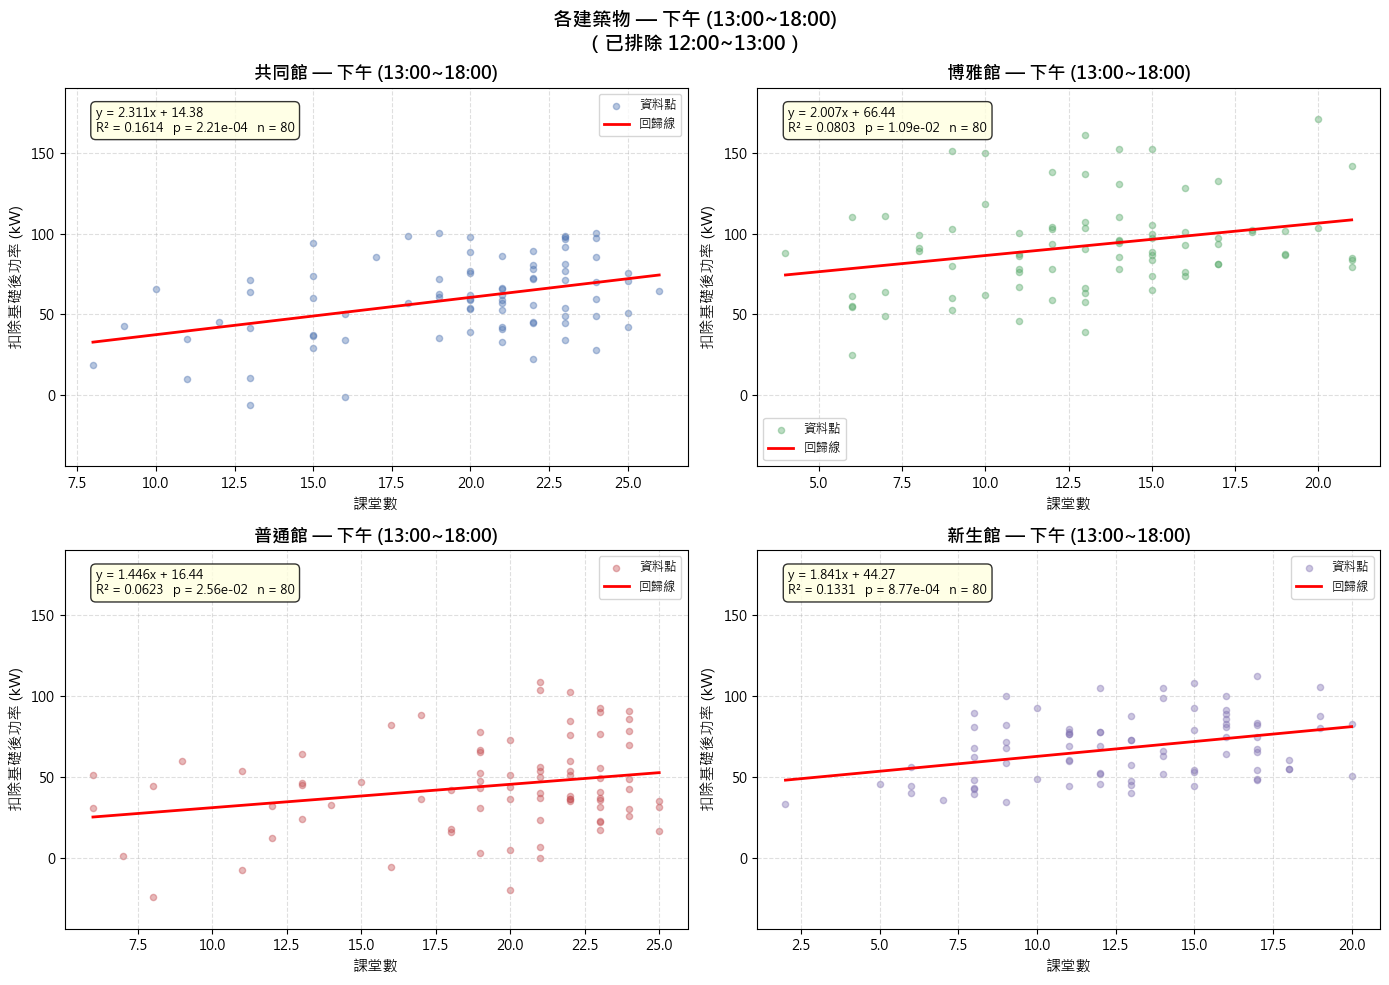

✅ 已存檔 Part2_afternoon_各建築.png


In [10]:
for period in ['morning', 'afternoon']:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'各建築物 — {PERIOD_LABEL[period]}\n（已排除 12:00~13:00）',
                 fontsize=14, fontweight='bold')

    # 計算此時段的共同 Y 軸範圍
    valid_dfs = [filter_by_time(all_data[b], period)
                 for b in BUILDINGS if b in all_data]
    ylim = get_ylim(valid_dfs)

    for i, bld in enumerate(BUILDINGS):
        ax = axes[i // 2][i % 2]
        if bld not in all_data or len(all_data[bld]) == 0:
            ax.set_visible(False)
            continue
        df = filter_by_time(all_data[bld], period)
        plot_regression(ax, df['課堂數'], df['扣除基礎後功率_kW'],
                        f'{bld}館 — {PERIOD_LABEL[period]}',
                        color=PALETTE[bld], ylim=ylim)

    plt.tight_layout()
    fname = f'Part2_{period}_各建築.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ 已存檔 {fname}')

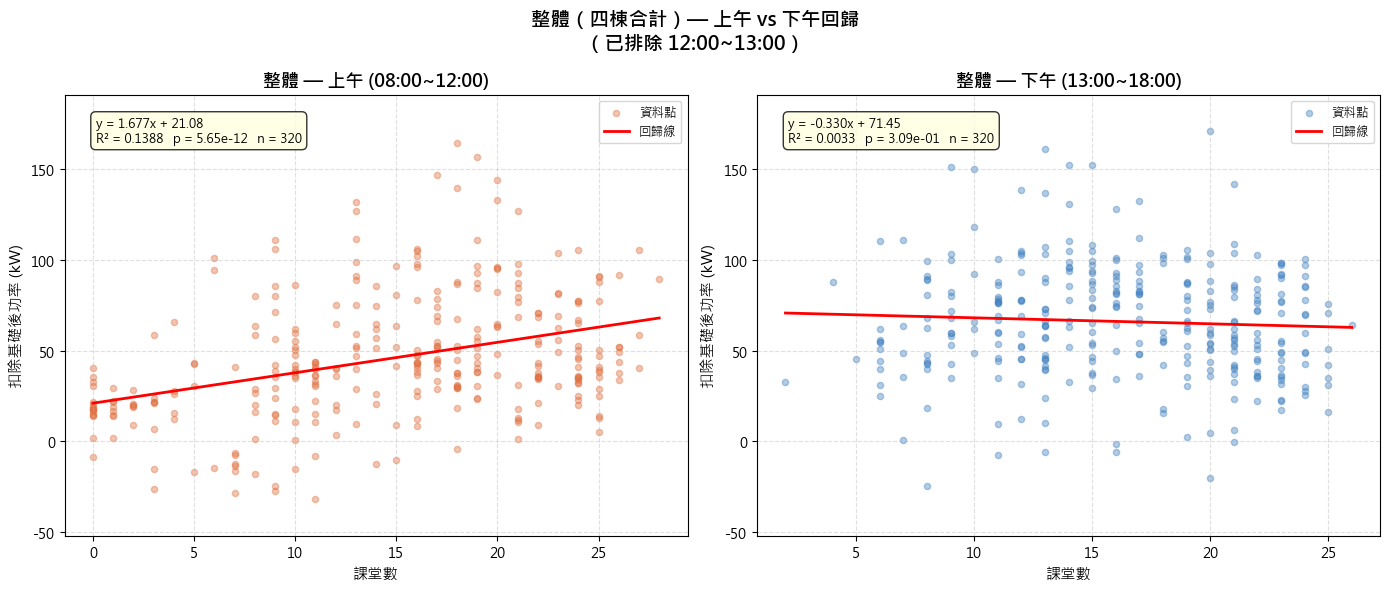

✅ 已存檔 Part2_整體_上下午.png


In [11]:
# ── Part 2：上午 / 下午 × 整體，共 2 子圖 ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('整體（四棟合計）— 上午 vs 下午回歸\n（已排除 12:00~13:00）',
             fontsize=14, fontweight='bold')

# 計算上下午合併的共同 Y 軸範圍
valid_dfs = [filter_by_time(df_all, p) for p in ['morning', 'afternoon']]
ylim = get_ylim(valid_dfs)

for i, period in enumerate(['morning', 'afternoon']):
    ax = axes[i]
    df = filter_by_time(df_all, period)
    plot_regression(ax, df['課堂數'], df['扣除基礎後功率_kW'],
                    f'整體 — {PERIOD_LABEL[period]}',
                    color=['#E07040', '#4080C0'][i], ylim=ylim)

plt.tight_layout()
plt.savefig('Part2_整體_上下午.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 已存檔 Part2_整體_上下午.png')

In [12]:
# ── 統計摘要表 ─────────────────────────────────────────────
rows = []
for period_key, period_label in [('all', '全時段（含午休）'),
                                   ('morning', '上午'),
                                   ('afternoon', '下午')]:
    for bld in list(BUILDINGS) + ['整體']:
        if bld == '整體':
            df = filter_by_time(df_all, period_key) if period_key != 'all' else df_all
        else:
            if bld not in all_data:
                continue
            df = filter_by_time(all_data[bld], period_key) if period_key != 'all' else all_data[bld]

        df = df.dropna(subset=['課堂數', '扣除基礎後功率_kW'])
        x  = df['課堂數'].values.astype(float)
        y  = df['扣除基礎後功率_kW'].values.astype(float)
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]
        if len(x) < 2:
            continue
        slope, intercept, r, p, se = stats.linregress(x, y)
        rows.append({
            '時段': period_label,
            '建築': bld,
            '筆數': len(x),
            '斜率': round(slope, 4),
            '截距': round(intercept, 3),
            'R²':   round(r**2, 4),
            'p值':  f'{p:.2e}'
        })

summary = pd.DataFrame(rows)
print('\n=== 線性回歸統計摘要 ===')
summary


=== 線性回歸統計摘要 ===


,時段,建築,筆數,斜率,截距,R²,p值
0,全時段（含午休）,共同,180,2.7311,1.302,0.2879,8.27e-15
1,全時段（含午休）,博雅,180,3.3725,46.227,0.3069,7.17e-16
2,全時段（含午休）,普通,180,0.9717,21.139,0.0530,1.87e-03
3,全時段（含午休）,新生,180,2.0664,30.419,0.2517,7.28e-13
4,全時段（含午休）,整體,720,0.8596,44.104,0.0308,2.18e-06
5,上午,共同,80,3.2560,-18.204,0.4941,3.65e-13
6,上午,博雅,80,4.5118,24.179,0.6165,6.62e-18
7,上午,普通,80,2.3387,-12.978,0.2747,6.05e-07
8,上午,新生,80,2.2804,14.526,0.5341,1.41e-14
9,上午,整體,320,1.6775,21.083,0.1388,5.65e-12


In [13]:
# ── 匯出摘要表為 Excel ────────────────────────────────────
summary.to_excel('regression_summary.xlsx', index=False)
print('✅ 統計摘要已匯出至 regression_summary.xlsx')

✅ 統計摘要已匯出至 regression_summary.xlsx
